In [6]:
import pandas as pd
import numpy as np
import seaborn as sns

In [7]:
!pip install matplotlib


In [8]:
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("Phishing_Legitimate_full.csv")
df.head()


,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,...,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,...,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,0,1
3,4,3,1,6,79,1,0,0,0,0,...,0,0,0,1,-1,1,1,1,-1,1
4,5,3,0,4,46,0,0,0,0,0,...,1,0,0,1,1,-1,0,-1,-1,1


In [10]:
df.columns

Index(['id', 'NumDots', 'SubdomainLevel', 'PathLevel', 'UrlLength', 'NumDash',
       'NumDashInHostname', 'AtSymbol', 'TildeSymbol', 'NumUnderscore',
       'NumPercent', 'NumQueryComponents', 'NumAmpersand', 'NumHash',
       'NumNumericChars', 'NoHttps', 'RandomString', 'IpAddress',
       'DomainInSubdomains', 'DomainInPaths', 'HttpsInHostname',
       'HostnameLength', 'PathLength', 'QueryLength', 'DoubleSlashInPath',
       'NumSensitiveWords', 'EmbeddedBrandName', 'PctExtHyperlinks',
       'PctExtResourceUrls', 'ExtFavicon', 'InsecureForms',
       'RelativeFormAction', 'ExtFormAction', 'AbnormalFormAction',
       'PctNullSelfRedirectHyperlinks', 'FrequentDomainNameMismatch',
       'FakeLinkInStatusBar', 'RightClickDisabled', 'PopUpWindow',
       'SubmitInfoToEmail', 'IframeOrFrame', 'MissingTitle',
       'ImagesOnlyInForm', 'SubdomainLevelRT', 'UrlLengthRT',
       'PctExtResourceUrlsRT', 'AbnormalExtFormActionR', 'ExtMetaScriptLinkRT',
       'PctExtNullSelfRedirectHyperl

In [11]:
df.shape

(10000, 50)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  10000 non-null  int64  
 1   NumDots                             10000 non-null  int64  
 2   SubdomainLevel                      10000 non-null  int64  
 3   PathLevel                           10000 non-null  int64  
 4   UrlLength                           10000 non-null  int64  
 5   NumDash                             10000 non-null  int64  
 6   NumDashInHostname                   10000 non-null  int64  
 7   AtSymbol                            10000 non-null  int64  
 8   TildeSymbol                         10000 non-null  int64  
 9   NumUnderscore                       10000 non-null  int64  
 10  NumPercent                          10000 non-null  int64  
 11  NumQueryComponents                  10000 

In [15]:
df.tail()

,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
9995,9996,3,1,1,50,0,0,0,0,0,...,0,0,0,1,1,-1,1,0,1,0
9996,9997,2,1,4,59,1,0,0,0,0,...,1,0,0,1,0,0,1,0,1,0
9997,9998,2,1,4,57,0,0,0,0,0,...,0,0,0,1,0,1,1,0,1,0
9998,9999,3,1,1,49,0,0,0,0,0,...,1,0,0,1,1,0,1,0,1,0
9999,10000,3,1,2,52,3,0,0,0,0,...,0,0,0,1,1,1,1,1,1,0


In [16]:
df.nunique()

id                                    10000
NumDots                                  17
SubdomainLevel                           13
PathLevel                                18
UrlLength                               226
NumDash                                  25
NumDashInHostname                        10
AtSymbol                                  2
TildeSymbol                               2
NumUnderscore                            16
NumPercent                               14
NumQueryComponents                       19
NumAmpersand                             16
NumHash                                   2
NumNumericChars                          82
NoHttps                                   2
RandomString                              2
IpAddress                                 2
DomainInSubdomains                        2
DomainInPaths                             2
HttpsInHostname                           1
HostnameLength                           74
PathLength                      

In [18]:
df['CLASS_LABEL'].value_counts()

CLASS_LABEL
1    5000
0    5000
Name: count, dtype: int64

In [21]:
df.isnull().sum()

id                                    0
NumDots                               0
SubdomainLevel                        0
PathLevel                             0
UrlLength                             0
NumDash                               0
NumDashInHostname                     0
AtSymbol                              0
TildeSymbol                           0
NumUnderscore                         0
NumPercent                            0
NumQueryComponents                    0
NumAmpersand                          0
NumHash                               0
NumNumericChars                       0
NoHttps                               0
RandomString                          0
IpAddress                             0
DomainInSubdomains                    0
DomainInPaths                         0
HttpsInHostname                       0
HostnameLength                        0
PathLength                            0
QueryLength                           0
DoubleSlashInPath                     0


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['id', 'numdots', 'subdomainlevel', 'pathlevel', 'urllength', 'numdash',
       'numdashinhostname', 'atsymbol', 'tildesymbol', 'numunderscore',
       'numpercent', 'numquerycomponents', 'numampersand', 'numhash',
       'numnumericchars', 'nohttps', 'randomstring', 'ipaddress',
       'domaininsubdomains', 'domaininpaths', 'httpsinhostname',
       'hostnamelength', 'pathlength', 'querylength', 'doubleslashinpath',
       'numsensitivewords', 'embeddedbrandname', 'pctexthyperlinks',
       'pctextresourceurls', 'extfavicon', 'insecureforms',
       'relativeformaction', 'extformaction', 'abnormalformaction',
       'pctnullselfredirecthyperlinks', 'frequentdomainnamemismatch',
       'fakelinkinstatusbar', 'rightclickdisabled', 'popupwindow',
       'submitinfotoemail', 'iframeorframe', 'missingtitle',
       'imagesonlyinform', 'subdomainlevelrt', 'urllengthrt',
       'pctextresourceurlsrt', 'abnormalextformactionr', 'extmetascriptlinkrt',
       'pctextnullselfredirecthyperl

In [25]:
df.describe()

,id,numdots,subdomainlevel,pathlevel,urllength,numdash,numdashinhostname,atsymbol,tildesymbol,numunderscore,...,iframeorframe,missingtitle,imagesonlyinform,subdomainlevelrt,urllengthrt,pctextresourceurlsrt,abnormalextformactionr,extmetascriptlinkrt,pctextnullselfredirecthyperlinksrt,class_label
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,...,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,2.445100,0.586800,3.300300,70.264100,1.818000,0.138900,0.000300,0.013100,0.32320,...,0.339600,0.03220,0.030400,0.956600,0.020200,0.353300,0.793200,0.173400,0.314100,0.500000
std,2886.89568,1.346836,0.751214,1.863241,33.369877,3.106258,0.545744,0.017319,0.113709,1.11466,...,0.473597,0.17654,0.171694,0.248037,0.820036,0.888908,0.521019,0.755771,0.897843,0.500025
min,1.00000,1.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.00000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,2500.75000,2.000000,0.000000,2.000000,48.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.00000,0.000000,1.000000,-1.000000,-1.000000,1.000000,0.000000,-1.000000,0.000000
50%,5000.50000,2.000000,1.000000,3.000000,62.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.500000
75%,7500.25000,3.000000,1.000000,4.000000,84.000000,2.000000,0.000000,0.000000,0.000000,0.00000,...,1.000000,0.00000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,10000.00000,21.000000,14.000000,18.000000,253.000000,55.000000,9.000000,1.000000,1.000000,18.00000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: ylabel='count'>

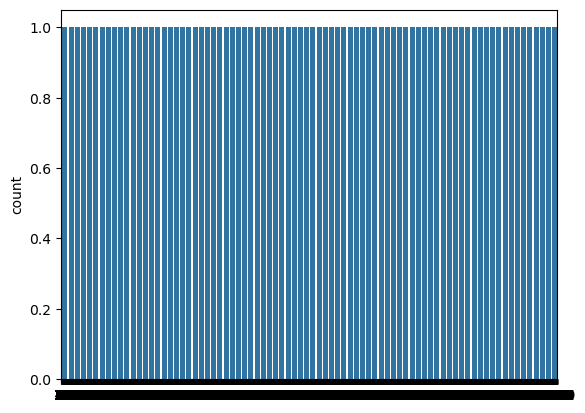

In [28]:
sns.countplot(df['numdots'])

In [57]:
shuffled_df = df.sample(frac=1).reset_index(drop=True)
shuffled_df.head()
shuffled_df.reset_index(inplace=True)
shuffled_df.drop('id',axis=1, inplace=True)

In [60]:
X = shuffled_df.iloc[:,:-1]
y = shuffled_df.iloc[:,-1]
X.drop('index', axis=1, inplace=True)
X

,numdots,subdomainlevel,pathlevel,urllength,numdash,numdashinhostname,atsymbol,tildesymbol,numunderscore,numpercent,...,submitinfotoemail,iframeorframe,missingtitle,imagesonlyinform,subdomainlevelrt,urllengthrt,pctextresourceurlsrt,abnormalextformactionr,extmetascriptlinkrt,pctextnullselfredirecthyperlinksrt
0,1,0,2,60,6,0,0,0,0,0,...,0,0,0,0,1,0,-1,1,0,1
1,3,1,3,79,0,0,0,0,0,0,...,0,0,0,0,1,-1,-1,1,-1,-1
2,3,1,5,62,1,0,0,0,0,0,...,1,0,0,0,1,0,1,1,1,1
3,4,0,3,71,0,0,0,0,2,0,...,0,0,0,0,1,0,1,1,0,0
4,2,1,2,31,1,1,0,0,0,0,...,1,0,0,0,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,4,1,5,66,0,0,0,0,0,0,...,0,1,0,1,1,0,1,1,-1,-1
9996,1,0,2,101,11,0,0,0,0,0,...,1,0,0,0,1,-1,-1,1,0,0
9997,2,0,2,114,11,0,0,0,0,0,...,0,1,0,0,1,-1,1,1,0,1
9998,2,0,3,50,0,0,0,0,0,0,...,0,1,0,0,1,1,-1,1,1,-1


In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [67]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)

In [68]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
y_pred = model.predict(X_test)

In [75]:
y_pred

array([0, 1, 0, ..., 1, 0, 1], shape=(2000,))

In [77]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print(f"accuracy of rf: {accuracy_score(y_test, y_pred)}")        
print(f"classification report of rf: {classification_report(y_test, y_pred)}")
print(f"confusion matrix of rf: {y_test, y_pred}")

accuracy of rf: 0.9805
classification report of rf:               precision    recall  f1-score   support

           0       0.98      0.98      0.98       988
           1       0.98      0.98      0.98      1012

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000

confusion matrix of rf: (6252    0
4684    1
1731    0
4742    0
4521    0
       ..
6412    0
8285    1
7853    1
1095    0
6929    1
Name: class_label, Length: 2000, dtype: int64, array([0, 1, 0, ..., 1, 0, 1], shape=(2000,)))


In [78]:
from sklearn import svm
svc = svm.SVC()

In [79]:
svc.fit(X_train,y_train)
svc_pred = svc.predict(X_test)

In [80]:
svc_accuracy = accuracy_score(y_test, svc_pred)
svc_classification_report = classification_report(y_test,svc_pred)
svc_confusion_matrix = confusion_matrix(y_test, svc_pred)


In [83]:
print(svc_accuracy)
print(svc_classification_report)
print(svc_confusion_matrix)

0.8525
              precision    recall  f1-score   support

           0       0.89      0.80      0.84       988
           1       0.82      0.90      0.86      1012

    accuracy                           0.85      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.86      0.85      0.85      2000

[[794 194]
 [101 911]]


In [84]:
scaled_data = df.copy()

In [85]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [88]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [104]:
svc = svm.SVC()
svc.fit(X_train_scaled,y_train)
svc_pred = svc.predict(X_test_scaled)
svc_accuracy = accuracy_score(y_test, svc_pred)
svc_classification_report = classification_report(y_test,svc_pred)
svc_confusion_matrix = confusion_matrix(y_test, svc_pred)
print(svc_accuracy)
print(svc_classification_report)
print(svc_confusion_matrix)

0.963
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       988
           1       0.96      0.97      0.96      1012

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000

[[947  41]
 [ 33 979]]


In [98]:
#google.com
print(model.predict([[2, 1, 0, 23, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 14, 1, 0, 0, 0, 1, 37.03703703703704, 0.0, 0, 0, 1, 0, 0, 0.0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 23, 0.0, 0, 0.0, 0]]))

[0]


/home/aaditya-pareek/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [99]:
#google.com
print(svc.predict([[2, 1, 0, 23, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 14, 1, 0, 0, 0, 1, 37.03703703703704, 0.0, 0, 0, 1, 0, 0, 0.0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 23, 0.0, 0, 0.0, 0]]))

[1]


In [100]:
#	https://serviczio.hgeaioxhtzgsgalo.ski/ ->phishing
print(model.predict([[2, 1, 0, 40, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 40, 0, 0, 0, 0]]))

[0]


/home/aaditya-pareek/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [101]:
#	https://serviczio.hgeaioxhtzgsgalo.ski/ -> phishing
print(svc.predict([[2, 1, 0, 40, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 30, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 40, 0, 0, 0, 0]]))

[1]


In [105]:
#https://51.79.248.38/wp-content/themes/twentytwentytwo/hr_aruba.html... ->phishing
print(model.predict([[7, 2, 4, 71, 1, 0, 0, 0, 1, 0, 0, 0, 0, 9, 0, 0, 1, 0, 0, 0, 12, 51, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 71, 0, 0, 0, 0]]))
print(svc.predict([[7, 2, 4, 71, 1, 0, 0, 0, 1, 0, 0, 0, 0, 9, 0, 0, 1, 0, 0, 0, 12, 51, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 71, 0, 0, 0, 0]]))

[1]
[1]


/home/aaditya-pareek/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [106]:
#https://mobilephotokiosk.app:443/view/1337 -> legitimate
print(model.predict([[1, 0, 2, 42, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 24, 10, 0, 0, 0, 0, 100.0, 42.857142857142854, 0, 0, 0, 0, 0, 0.0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 42, 42.857142857142854, 0, 0.0, 0]]))
print(svc.predict([[1, 0, 2, 42, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 24, 10, 0, 0, 0, 0, 100.0, 42.857142857142854, 0, 0, 0, 0, 0, 0.0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 42, 42.857142857142854, 0, 0.0, 0]]))

[0]
[1]


/home/aaditya-pareek/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [107]:
#https://supporto-cherrybank.com/index.php -> phishing
print(model.predict([[2, 0, 1, 41, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 23, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 41, 0, 0, 0, 0]]))
print(svc.predict([[2, 0, 1, 41, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 23, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 41, 0, 0, 0, 0]]))

[0]
[1]


/home/aaditya-pareek/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [109]:
import numpy as np

diff_idx = np.where(y_pred != svc_pred)[0]
print(f"Models disagree on {len(diff_idx)} out of {len(y_test)} samples")


Models disagree on 63 out of 2000 samples


In [111]:
df_diff = X_test.iloc[diff_idx].copy()
df_diff['true'] = y_test.iloc[diff_idx].values
df_diff['y_pred'] = y_pred[diff_idx]
df_diff['svc_pred'] = svc_pred[diff_idx]
df_diff.head()

,numdots,subdomainlevel,pathlevel,urllength,numdash,numdashinhostname,atsymbol,tildesymbol,numunderscore,numpercent,...,imagesonlyinform,subdomainlevelrt,urllengthrt,pctextresourceurlsrt,abnormalextformactionr,extmetascriptlinkrt,pctextnullselfredirecthyperlinksrt,true,y_pred,svc_pred
7938,3,1,2,136,11,0,0,0,0,0,...,0,1,-1,-1,0,-1,-1,0,1,0
9655,2,0,2,96,3,0,0,0,0,0,...,0,1,-1,1,1,0,1,0,0,1
9054,3,1,3,44,2,2,0,0,0,0,...,0,1,1,1,1,1,1,1,1,0
3006,2,1,6,95,0,0,0,0,8,0,...,0,1,-1,-1,-1,0,-1,0,1,0
7887,2,0,2,27,0,0,0,0,0,0,...,0,1,1,1,1,1,1,0,0,1


In [113]:
rf_correct = (y_pred == y_test)
svc_correct = (svc_pred == y_test)

print(f"RF correct on {rf_correct.sum()} samples")
print(f"SVC correct on {svc_correct.sum()} samples")


RF correct on 1961 samples
SVC correct on 1926 samples


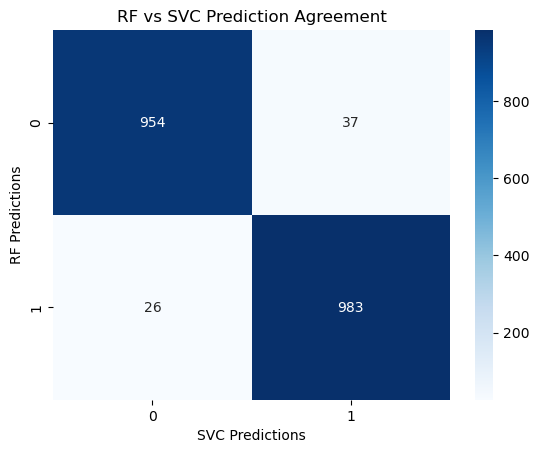

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_pred, svc_pred), annot=True, fmt="d", cmap="Blues")
plt.title("RF vs SVC Prediction Agreement")
plt.xlabel("SVC Predictions")
plt.ylabel("RF Predictions")
plt.show()


In [115]:
from sklearn.ensemble import VotingClassifier

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

ensemble = VotingClassifier(
    estimators=[('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
                ('svc', SVC(kernel='rbf', probability=True, random_state=42))],
    voting='soft'   # uses average probabilities
)
ensemble.fit(X_train_scaled, y_train)


,estimators,"[('rf', ...), ('svc', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [116]:
ensemble_pred = ensemble.predict(X_test)

/home/aaditya-pareek/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/aaditya-pareek/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [118]:
print(f"accuracy score of ensemble_pred: {accuracy_score(ensemble_pred, y_test)}")
print(f"classification report of ensemble_pred: {classification_report(ensemble_pred, y_test)}")
print(f"confusion matrix of ensemble_pred: {confusion_matrix(ensemble_pred, y_test)}")

accuracy score of ensemble_pred: 0.52
classification report of ensemble_pred:               precision    recall  f1-score   support

           0       0.21      0.54      0.30       380
           1       0.83      0.52      0.64      1620

    accuracy                           0.52      2000
   macro avg       0.52      0.53      0.47      2000
weighted avg       0.71      0.52      0.57      2000

confusion matrix of ensemble_pred: [[204 176]
 [784 836]]


In [119]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

svc = SVC(kernel='rbf', probability=True, random_state=42)
svc_calibrated = CalibratedClassifierCV(svc, cv=5)

rf = RandomForestClassifier(n_estimators=200, random_state=42)

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('svc', svc_calibrated)],
    voting='soft'
)

ensemble.fit(X_train_scaled, y_train)
ensemble_pred = ensemble.predict(X_test_scaled)


In [120]:
print("Ensemble accuracy:", accuracy_score(y_test, ensemble_pred))


Ensemble accuracy: 0.9735


In [121]:
#https://supporto-cherrybank.com/index.php -> phishing
print(ensemble.predict([[2, 0, 1, 41, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 23, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 41, 0, 0, 0, 0]]))


[0]


In [122]:
#https://mobilephotokiosk.app:443/view/1337 -> legitimate
print(ensemble.predict([[1, 0, 2, 42, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 24, 10, 0, 0, 0, 0, 100.0, 42.857142857142854, 0, 0, 0, 0, 0, 0.0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 42, 42.857142857142854, 0, 0.0, 0]]))


[1]
